In [1]:
import xarray as xr
import numpy as np
import rioxarray as rio
import matplotlib.pyplot as plt

In [2]:
def fire_season(month):
    return (month >= 5) & (month <= 10)    
    
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

def get_variance(arr):
    return(scipy.stats.variation(arr))

def get_mannkendall_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = mk.original_test(arr).slope
        
    return(result)
   
def get_mannkendall_p(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = mk.original_test(arr).p
        
    return(result)


In [21]:
# ERA5 land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/static/land_sea_mask.nc')
lsm = lsm.isel(time=0).drop('time')


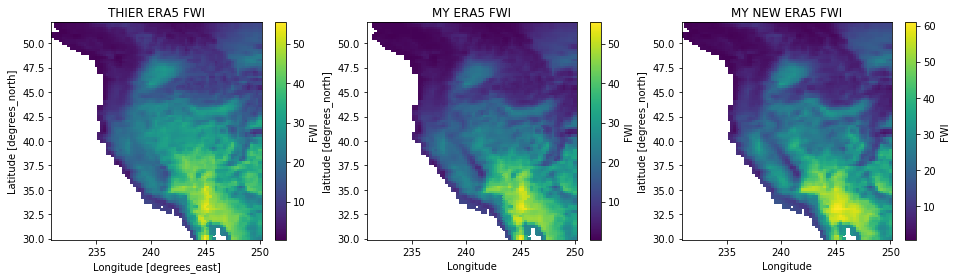

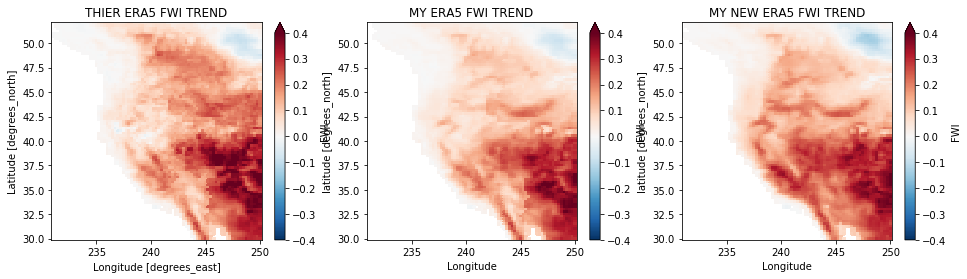

In [13]:
'''
ERA5

THIER v OLD_MINE v NEW_MINE daily mean and trend ERA5 FWI (1980-2020)
'''

their_era5_FWI = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/published_ERA5/FWI/FWI_1980_2020.nc")

my_era5_FWI = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/ideal-style/ERA5_FWI.nc")
my_era5_FWI['longitude'] = np.array([val+360 for val in my_era5_FWI.longitude])
my_era5_FWI = my_era5_FWI.sel(time=slice(their_era5_FWI.Time[0],their_era5_FWI.Time[-1]))
my_era5_FWI = my_era5_FWI.rename({'latitude':'Latitude','longitude':'Longitude','time':'Time'})

new_era5_FWI = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/ERA5_FWI_1951-2021.nc").FWI.sel(time=slice('1980','2020'))
new_era5_FWI = new_era5_FWI.where(lsm.lsm > 0)
new_era5_FWI['longitude'] = np.array([val+360 for val in new_era5_FWI.longitude])
new_era5_FWI = new_era5_FWI.rename({'latitude':'Latitude','longitude':'Longitude','time':'Time'})
new_era5_FWI = new_era5_FWI.sel(Time=slice(their_era5_FWI.Time[0],their_era5_FWI.Time[-1]),Latitude=slice(my_era5_FWI.Latitude[0].data,my_era5_FWI.Latitude[-1].data),Longitude=slice(my_era5_FWI.Longitude[0].data,my_era5_FWI.Longitude[-1].data))

their_era5_FWI = their_era5_FWI.sel(Latitude=slice(my_era5_FWI.Latitude[0].data,my_era5_FWI.Latitude[-1].data),Longitude=slice(my_era5_FWI.Longitude[0].data,my_era5_FWI.Longitude[-1].data))

# MEAN
fig,axs = plt.subplots(1,3,figsize=(16,4))
axs = axs.flatten()

their_era5_FWI.FWI.mean('Time').plot(ax=axs[0])
my_era5_FWI.FWI.mean('Time').plot(ax=axs[1])
new_era5_FWI.mean('Time').plot(ax=axs[2])

axs[0].set_title("THIER ERA5 FWI")
axs[1].set_title("MY ERA5 FWI")
axs[2].set_title("MY NEW ERA5 FWI")

plt.show()
plt.close()

# TREND
fig,axs = plt.subplots(1,3,figsize=(16,4))
axs = axs.flatten()

annual_theirs = their_era5_FWI.FWI.resample(Time='A').mean()
annual_old = my_era5_FWI.FWI.resample(Time='A').mean()
annual_new = new_era5_FWI.resample(Time='A').mean()

xr.apply_ufunc(get_linregress_slope, annual_theirs, input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[0],vmin=-0.4,vmax=0.4,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, annual_old, input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[1],vmin=-0.4,vmax=0.4,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, annual_new, input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[2],vmin=-0.4,vmax=0.4,cmap='RdBu_r')

axs[0].set_title("THIER ERA5 FWI TREND")
axs[1].set_title("MY ERA5 FWI TREND")
axs[2].set_title("MY NEW ERA5 FWI TREND")

plt.show()
plt.close()


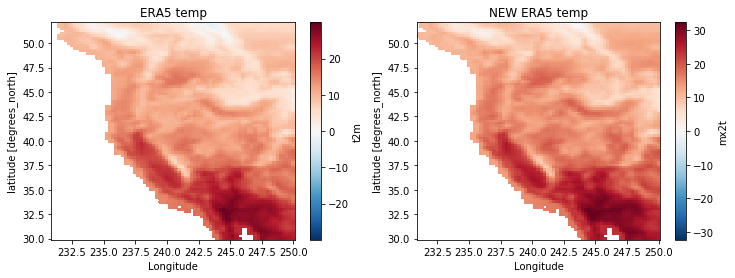

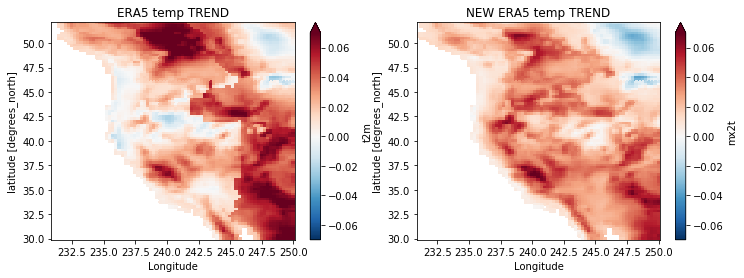

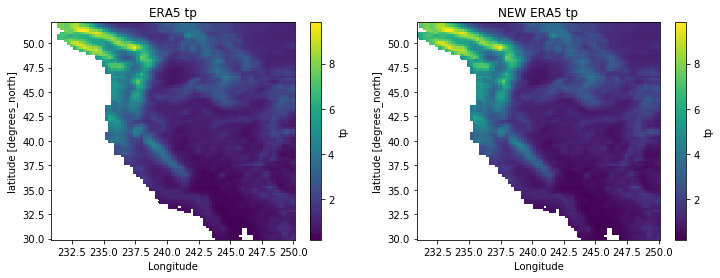

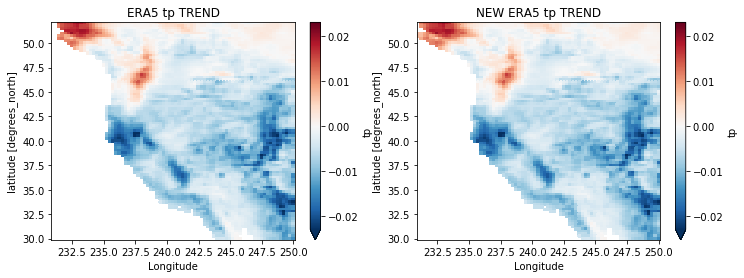

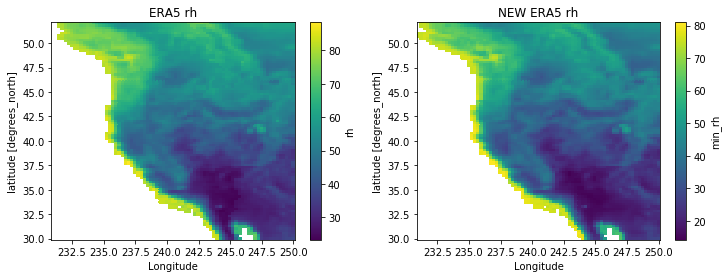

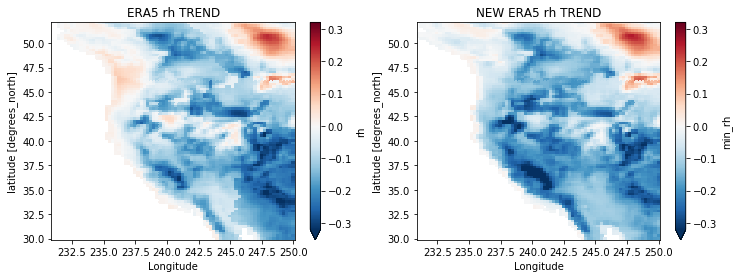

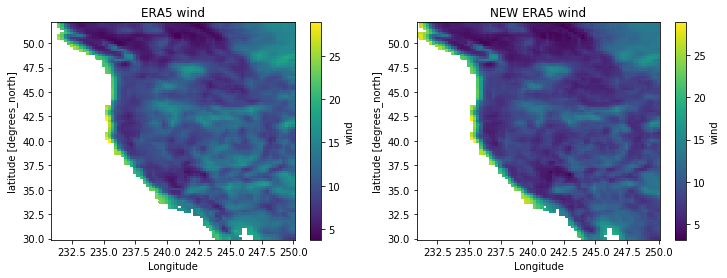

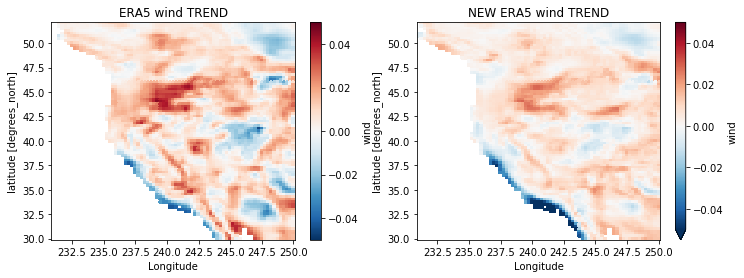

In [16]:
'''
ERA5 inputs

OLD v NEW ERA5 FWI inputs, daily mean (1980 - 2020)
'''
'''
my_era5_inputs = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/ideal-style/ERA5_FWI_inputs.nc").sel(time=slice('1980','2020'))
my_era5_inputs['longitude'] = np.array([val+360 for val in my_era5_inputs.longitude])
my_era5_inputs = my_era5_inputs.rename({'latitude':'Latitude','longitude':'Longitude','time':'Time'})
my_era5_inputs = my_era5_inputs.resample(Time = 'A').mean()

new_era5_inputs = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/inputs_1951-2021.nc").sel(time=slice('1980','2020'))
new_era5_inputs = new_era5_inputs.where(lsm.lsm > 0)
new_era5_inputs['longitude'] = np.array([val+360 for val in new_era5_inputs.longitude])
new_era5_inputs = new_era5_inputs.rename({'latitude':'Latitude','longitude':'Longitude','time':'Time'})
new_era5_inputs = new_era5_inputs.sel(Latitude=slice(my_era5_inputs.Latitude[0].data,my_era5_inputs.Latitude[-1].data),Longitude=slice(my_era5_inputs.Longitude[0].data,my_era5_inputs.Longitude[-1].data))
new_era5_inputs = new_era5_inputs.resample(Time = 'A').mean()

var_dict = {'temp':['t2m','mx2t'],'tp':['tp','tp'],'rh':['rh','min_rh'],'wind':['wind','wind']}
'''
range_dict = {'temp':[-0.07,0.07],'tp':[-0.023,0.023],'rh':[-0.32,0.32],'wind':[-0.05,0.05]}
for var in var_dict:
    
    # MEAN
    fig,axs = plt.subplots(1,2,figsize=(12,4))
    axs = axs.flatten()

    my_era5_inputs[var_dict[var][0]].mean('Time').plot(ax=axs[0])
    new_era5_inputs[var_dict[var][1]].mean('Time').plot(ax=axs[1])

    axs[0].set_title("ERA5 "+var)
    axs[1].set_title("NEW ERA5 "+var)
    
    plt.show()
    plt.close()

    # TREND
    fig,axs = plt.subplots(1,2,figsize=(12,4))
    axs = axs.flatten()

    xr.apply_ufunc(get_linregress_slope, my_era5_inputs[var_dict[var][0]], input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[0],vmin=range_dict[var][0],vmax=range_dict[var][1],cmap='RdBu_r')
    xr.apply_ufunc(get_linregress_slope, new_era5_inputs[var_dict[var][1]], input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[1],vmin=range_dict[var][0],vmax=range_dict[var][1],cmap='RdBu_r')

    axs[0].set_title("ERA5 "+var+" TREND")
    axs[1].set_title("NEW ERA5 "+var+" TREND")

    plt.show()
    plt.close()


#plt.savefig("FWI_compare.png",dpi=300)

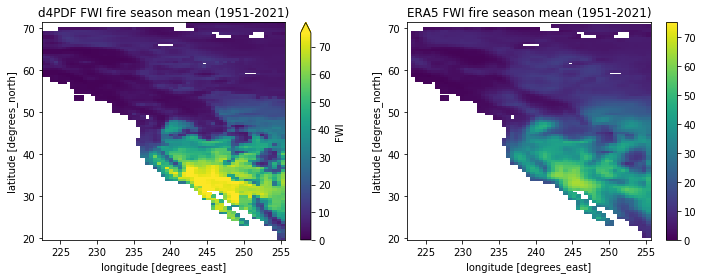

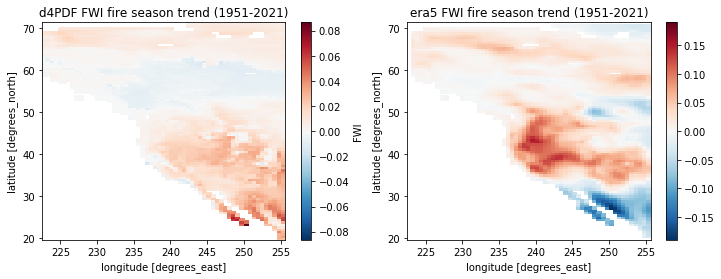

In [18]:
'''
ERA5 + MODEL 1951-

NEW ERA5 vs d4PDF, 6month fire season mean (1951 - 2021)
'''

# d4pdf 
model_FWI = xr.open_dataarray("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc")

# model-style ERA5
era5_FWI = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_6month_fire_season_model_grid.nc')

# MEAN
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

model_FWI.mean('time').plot(ax=axs[0],vmin=0,vmax=75)
era5_FWI.mean('time').plot(ax=axs[1],vmin=0,vmax=75)

axs[0].set_title('d4PDF FWI fire season mean (1951-2021)')
axs[1].set_title('ERA5 FWI fire season mean (1951-2021)')

# TREND
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

xr.apply_ufunc(get_linregress_slope, model_FWI, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0])#,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, era5_FWI, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1])#,cmap='RdBu_r')

axs[0].set_title("d4PDF FWI fire season trend (1951-2021)")
axs[1].set_title("era5 FWI fire season trend (1951-2021)")

plt.show()
plt.close()

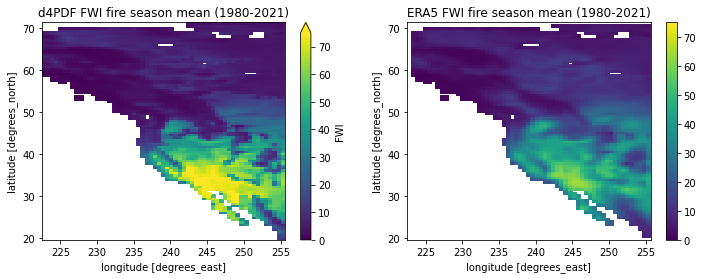

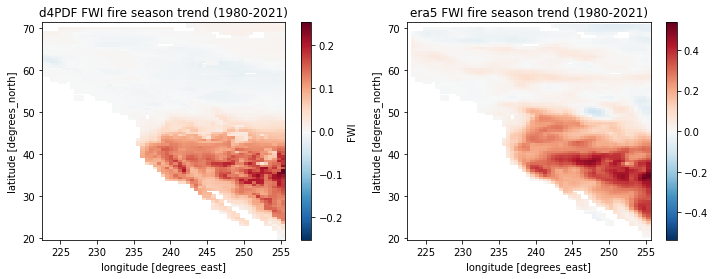

In [4]:
'''
ERA5 + MODEL 1980-

NEW ERA5 vs d4PDF, 6month fire season mean (1980 - 2021)
'''

# d4pdf 
model_FWI = xr.open_dataarray("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc")
model_FWI = model_FWI.sel(time=slice("1980","2021"))
# model-style ERA5
era5_FWI = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_6month_fire_season_model_grid.nc')
era5_FWI = era5_FWI.sel(time=slice("1980","2021"))

# MEAN
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

model_FWI.mean('time').plot(ax=axs[0],vmin=0,vmax=75)
era5_FWI.mean('time').plot(ax=axs[1],vmin=0,vmax=75)

axs[0].set_title('d4PDF FWI fire season mean (1980-2021)')
axs[1].set_title('ERA5 FWI fire season mean (1980-2021)')

# TREND
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

xr.apply_ufunc(get_linregress_slope, model_FWI, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0],vmin=)#,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, era5_FWI, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1])#,cmap='RdBu_r')

axs[0].set_title("d4PDF FWI fire season trend (1980-2021)")
axs[1].set_title("era5 FWI fire season trend (1980-2021)")

plt.show()
plt.close()

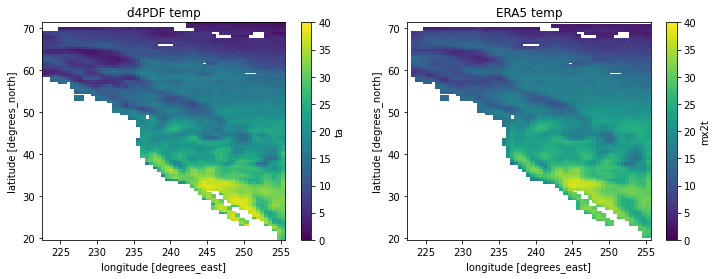

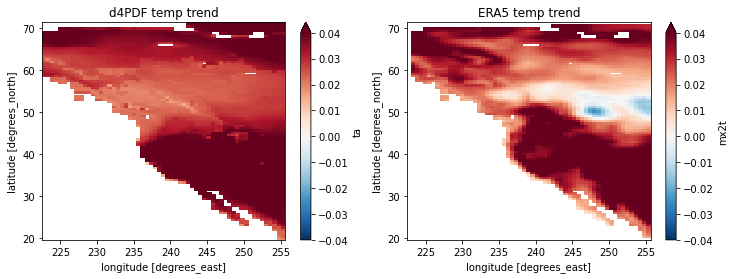

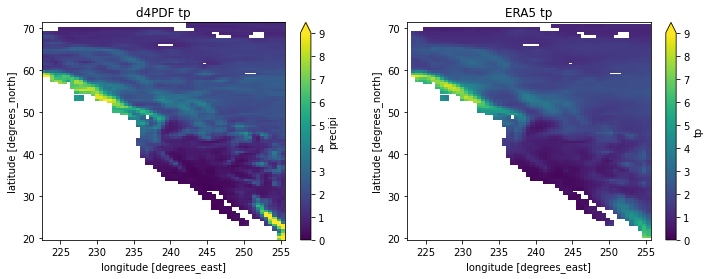

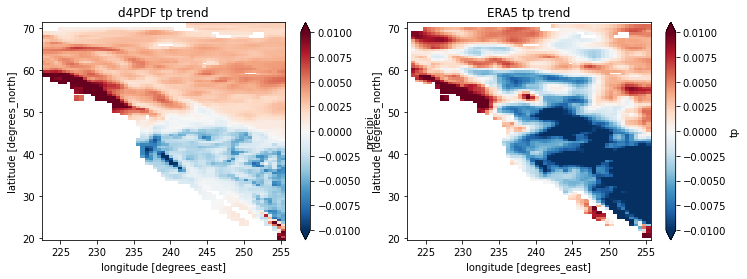

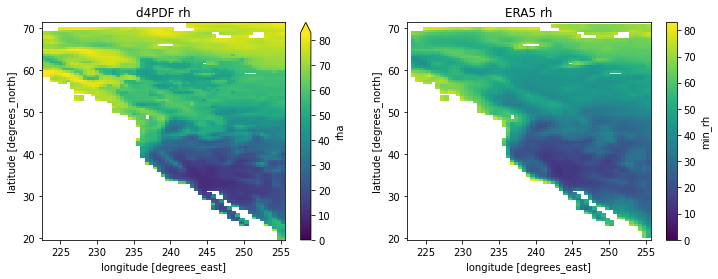

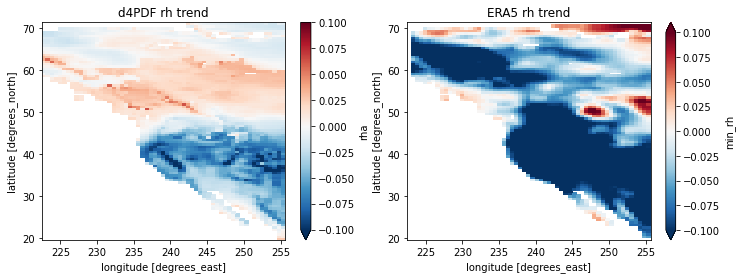

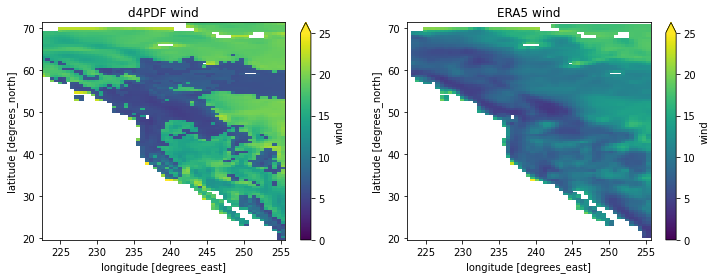

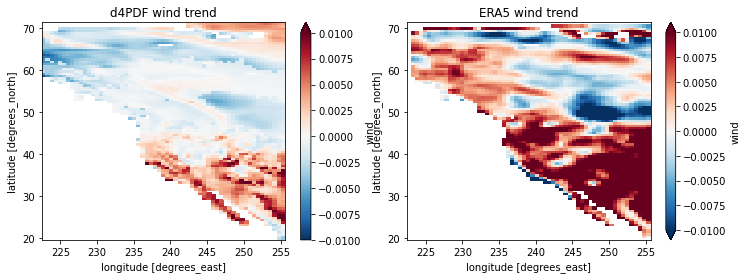

In [5]:
'''
ERA5 + MODEL inputs

NEW ERA5 vs d4PDF FWI inputs, 6 month fire season mean (1951 - 2021)
'''

def fire_season(month):
    return (month >= 5) & (month <= 10)    

# d4pdf 
model_inputs = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/HPB/FWI_inputs_HPB_ensMean_1951-2021.nc")
months_selected = model_inputs.sel(time=fire_season(model_inputs['time.month']))
model_inputs = months_selected.resample(time ='A').mean('time')
model_inputs = model_inputs.sel(time=slice("1980","2021"))

# ERA5 inputs
new_era5_inputs = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_inputs_6month_fire_season_model_grid.nc")
new_era5_inputs = new_era5_inputs.sel(time=slice("1980","2021"))

var_dict = {'temp':['ta','mx2t'],'tp':['precipi','tp'],'rh':['rha','min_rh'],'wind':['wind','wind']}
t_range_dict = {'temp':[-0.04,0.04],'tp':[-0.01,0.01],'rh':[-0.1,0.1],'wind':[-0.01,0.01]}
m_range_dict = {'temp':[0,40],'tp':[0,9],'rh':[0,83],'wind':[0,25]}

for var in var_dict:
    
    model_da = model_inputs[var_dict[var][0]]
    era5_da = new_era5_inputs[var_dict[var][1]]

    # MEAN
    fig,axs = plt.subplots(1,2,figsize=(12,4))
    axs = axs.flatten()
    
    model_da.mean('time').plot(ax=axs[0],vmin=m_range_dict[var][0],vmax=m_range_dict[var][1])
    era5_da.mean('time').plot(ax=axs[1],vmin=m_range_dict[var][0],vmax=m_range_dict[var][1])
    
    axs[0].set_title("d4PDF "+var)
    axs[1].set_title("ERA5 "+var)
    
    plt.show()
    plt.close()
    
    # trend
    fig,axs = plt.subplots(1,2,figsize=(12,4))
    axs = axs.flatten()
    
    xr.apply_ufunc(get_linregress_slope, model_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0],vmin=t_range_dict[var][0],vmax=t_range_dict[var][1],cmap='RdBu_r')
    xr.apply_ufunc(get_linregress_slope, era5_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1],vmin=t_range_dict[var][0],vmax=t_range_dict[var][1],cmap='RdBu_r')
    
    axs[0].set_title("d4PDF "+var+" trend")
    axs[1].set_title("ERA5 "+var+" trend")
    
    plt.show()
    plt.close()


#plt.savefig("FWI_compare.png",dpi=300)

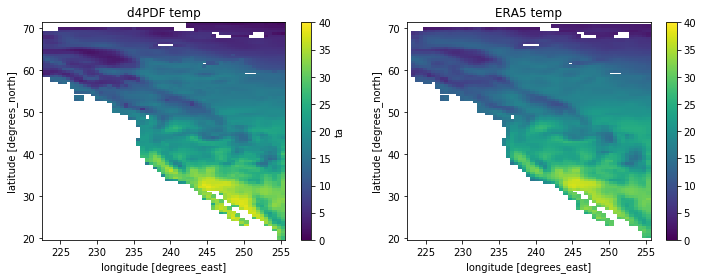

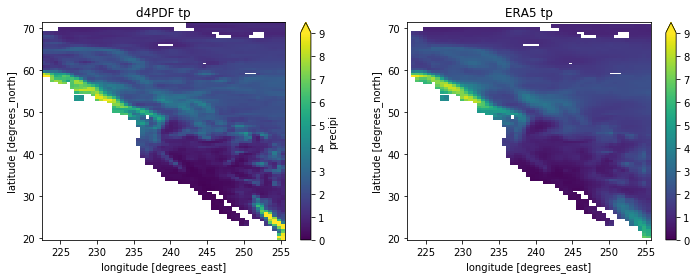

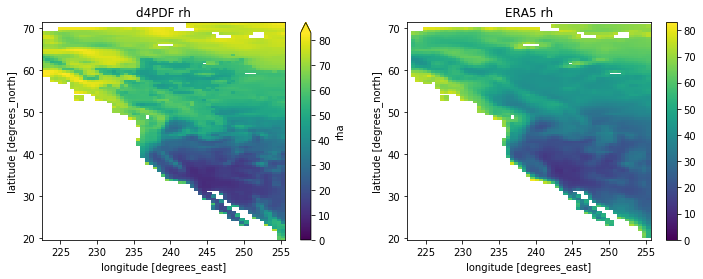

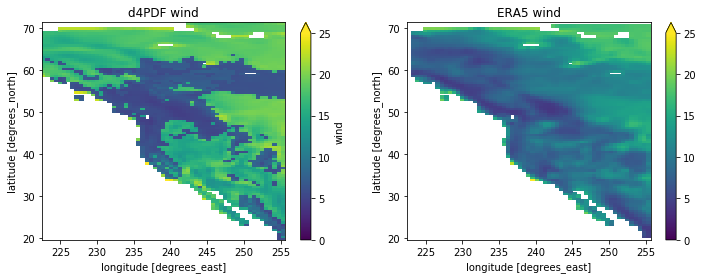

In [29]:
'''
NEW ERA5 vs d4PDF FWI inputs, 6 month fire season mean (1951 - 2021)
'''

def fire_season(month):
    return (month >= 5) & (month <= 10)    

# d4pdf 
model_inputs = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/HPB/FWI_inputs_HPB_ensMean_1951-2021.nc")
months_selected = model_inputs.sel(time=fire_season(model_inputs['time.month']))
model_inputs = months_selected.resample(time ='A').mean('time')

# ERA5 inputs
new_era5_inputs = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/inputs_1951-2021.nc")
months_selected = new_era5_inputs.sel(time=fire_season(new_era5_inputs['time.month']))
new_era5_inputs = months_selected.resample(time ='A').mean('time')

var_dict = {'temp':['ta','mx2t'],'tp':['precipi','tp'],'rh':['rha','min_rh'],'wind':['wind','wind']}
range_dict = {'temp':[0,40],'tp':[0,9],'rh':[0,83],'wind':[0,25]}

for var in var_dict:
    
    fig,axs = plt.subplots(1,2,figsize=(12,4))
    axs = axs.flatten()

    model_da = model_inputs[var_dict[var][0]]
    era5_da = new_era5_inputs[var_dict[var][1]]
    era5_da['longitude'] = [lon + 360 for lon in era5_da.longitude.data]
    era5_da = era5_da.coarsen(latitude=3,longitude=3,boundary='pad').mean()
    era5_da = era5_da.interp(longitude=model_da.lon, latitude=model_da.lat, method="linear")
    era5_da = era5_da.where(~model_da.isnull())
    
    model_da.mean('time').plot(ax=axs[0],vmin=range_dict[var][0],vmax=range_dict[var][1])
    era5_da.mean('time').plot(ax=axs[1],vmin=range_dict[var][0],vmax=range_dict[var][1])
    
    axs[0].set_title("d4PDF "+var)
    axs[1].set_title("ERA5 "+var)
    
    plt.show()
    plt.close()


#plt.savefig("FWI_compare.png",dpi=300)

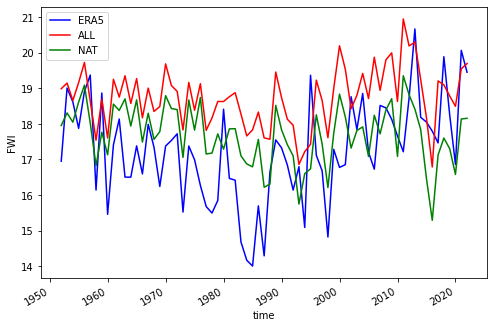

In [5]:
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_6month_fire_season_model_grid.nc')
HPB = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc')
HPB_NAT = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_NAT_ensMean.nc')

fig,axs = plt.subplots(figsize=(8,5))
ERA5.mean(['latitude','longitude']).plot(c='blue',label = 'ERA5')
HPB.mean(['latitude','longitude']).plot(c='red',label = 'ALL')
HPB_NAT.mean(['latitude','longitude']).plot(c='green',label = 'NAT')

axs.legend()

In [7]:
ERA5.time

<xarray.DataArray 'time' (time: 71)>
array(['1951-12-31T00:00:00.000000000', '1952-12-31T00:00:00.000000000',
       '1953-12-31T00:00:00.000000000', '1954-12-31T00:00:00.000000000',
       '1955-12-31T00:00:00.000000000', '1956-12-31T00:00:00.000000000',
       '1957-12-31T00:00:00.000000000', '1958-12-31T00:00:00.000000000',
       '1959-12-31T00:00:00.000000000', '1960-12-31T00:00:00.000000000',
       '1961-12-31T00:00:00.000000000', '1962-12-31T00:00:00.000000000',
       '1963-12-31T00:00:00.000000000', '1964-12-31T00:00:00.000000000',
       '1965-12-31T00:00:00.000000000', '1966-12-31T00:00:00.000000000',
       '1967-12-31T00:00:00.000000000', '1968-12-31T00:00:00.000000000',
       '1969-12-31T00:00:00.000000000', '1970-12-31T00:00:00.000000000',
       '1971-12-31T00:00:00.000000000', '1972-12-31T00:00:00.000000000',
       '1973-12-31T00:00:00.000000000', '1974-12-31T00:00:00.000000000',
       '1975-12-31T00:00:00.000000000', '1976-12-31T00:00:00.000000000',
       '1977-12-31T00:00:00.000000000', '1978-12-31T00:00:00.000000000',
       '1979-12-31T00:00:00.000000000', '1980-12-31T00:00:00.000000000',
       '1981-12-31T00:00:00.000000000', '1982-12-31T00:00:00.000000000',
       '1983-12-31T00:00:00.000000000', '1984-12-31T00:00:00.000000000',
       '1985-12-31T00:00:00.000000000', '1986-12-31T00:00:00.000000000',
       '1987-12-31T00:00:00.000000000', '1988-12-31T00:00:00.000000000',
       '1989-12-31T00:00:00.000000000', '1990-12-31T00:00:00.000000000',
       '1991-12-31T00:00:00.000000000', '1992-12-31T00:00:00.000000000',
       '1993-12-31T00:00:00.000000000', '1994-12-31T00:00:00.000000000',
       '1995-12-31T00:00:00.000000000', '1996-12-31T00:00:00.000000000',
       '1997-12-31T00:00:00.000000000', '1998-12-31T00:00:00.000000000',
       '1999-12-31T00:00:00.000000000', '2000-12-31T00:00:00.000000000',
       '2001-12-31T00:00:00.000000000', '2002-12-31T00:00:00.000000000',
       '2003-12-31T00:00:00.000000000', '2004-12-31T00:00:00.000000000',
       '2005-12-31T00:00:00.000000000', '2006-12-31T00:00:00.000000000',
       '2007-12-31T00:00:00.000000000', '2008-12-31T00:00:00.000000000',
       '2009-12-31T00:00:00.000000000', '2010-12-31T00:00:00.000000000',
       '2011-12-31T00:00:00.000000000', '2012-12-31T00:00:00.000000000',
       '2013-12-31T00:00:00.000000000', '2014-12-31T00:00:00.000000000',
       '2015-12-31T00:00:00.000000000', '2016-12-31T00:00:00.000000000',
       '2017-12-31T00:00:00.000000000', '2018-12-31T00:00:00.000000000',
       '2019-12-31T00:00:00.000000000', '2020-12-31T00:00:00.000000000',
       '2021-12-31T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1951-12-31 1952-12-31 ... 2021-12-31

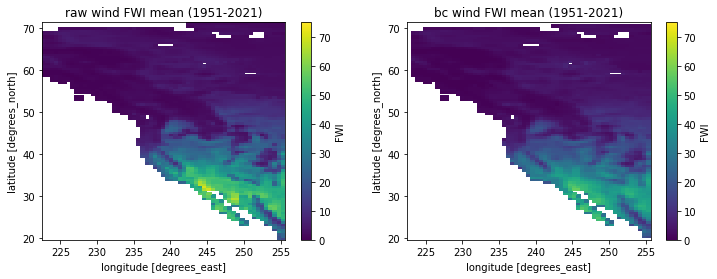

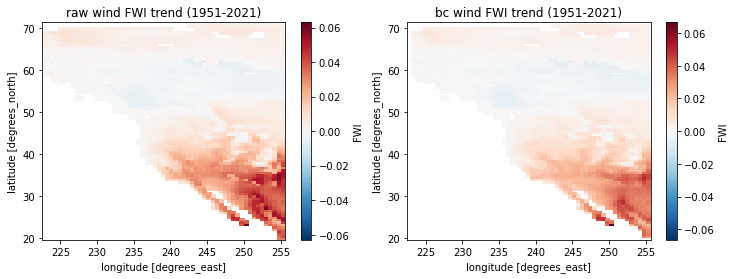

In [4]:
'''
MODEL

raw wind vs. bias correct wind FWI
'''

# raw wind FWI 
raw_FWI = xr.open_dataarray("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_ensMean.nc")
raw_FWI = raw_FWI.sel(time=slice("1951","2021")).resample(time='A').mean()
# BC wind FWI
bc_FWI = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/daily/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
bc_FWI = bc_FWI.sel(time=slice("1951","2021")).resample(time='A').mean()

# MEAN
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

raw_FWI.mean('time').plot(ax=axs[0],vmin=0,vmax=75)
bc_FWI.mean('time').plot(ax=axs[1],vmin=0,vmax=75)

axs[0].set_title('raw wind FWI mean (1951-2021)')
axs[1].set_title('bc wind FWI mean (1951-2021)')

# TREND
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

xr.apply_ufunc(get_linregress_slope, raw_FWI, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0])#,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, bc_FWI, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1])#,cmap='RdBu_r')

axs[0].set_title("raw wind FWI trend (1951-2021)")
axs[1].set_title("bc wind FWI trend (1951-2021)")

plt.show()
plt.close()

In [52]:
'''
ERA5 vs d4PDF vs CAM5
'''
def fire_season(month):
    return (month >= 5) & (month <= 10)

# FWI
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

# FWI inputs
ERA5_inputs = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_inputs_6month_fire_season_ERA5_resolution.nc')
cam5_inputs = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_All_ensMean.nc')

d4pdf_inputs = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_HPB_ensMean.nc')
d4pdf_wind =  xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/BC_wind/BC_WIND_HPB_ensMean_1951-2021.nc')
d4pdf_wind = d4pdf_wind.sel(time=fire_season(d4pdf_wind['time.month'])).resample(time='A').mean('time')
d4pdf_inputs = xr.merge([d4pdf_inputs.drop('wind'),d4pdf_wind])


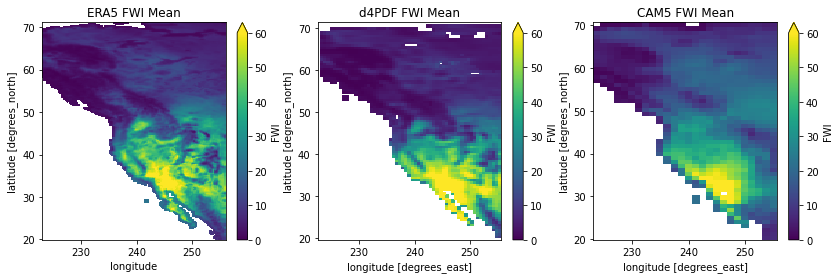

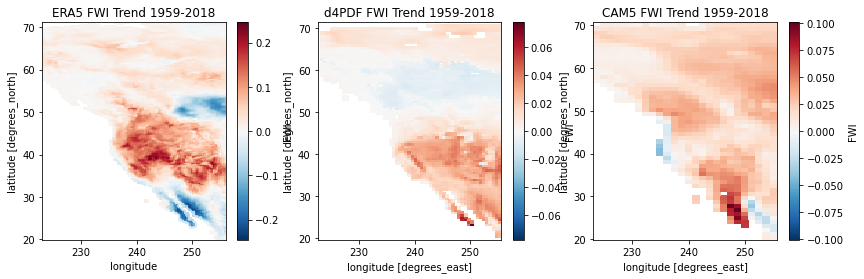

In [56]:
for method in ['mean','trend']:
    fig,axs = plt.subplots(1,3,figsize=(14,4))
    axs = axs.flatten()

    das = [ERA5, d4pdf, cam5]
    names = ['ERA5','d4PDF','CAM5']

    for i,da in enumerate(das):
        da = da.sel(time=slice("1959","2018"))

        if method == 'mean':
            da.mean('time').plot(ax=axs[i],vmin=0,vmax=60)
            axs[i].set_title(names[i] + " FWI Mean")
            
        if method == 'trend':
            xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],cmap='RdBu_r')
            axs[i].set_title(names[i] + " FWI Trend 1959-2018")
            
    plt.show()
    plt.close(fig)
            

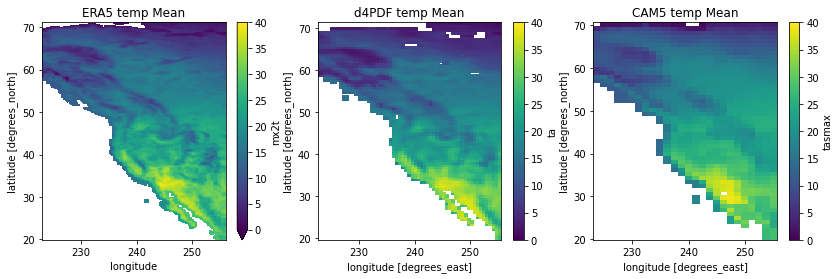

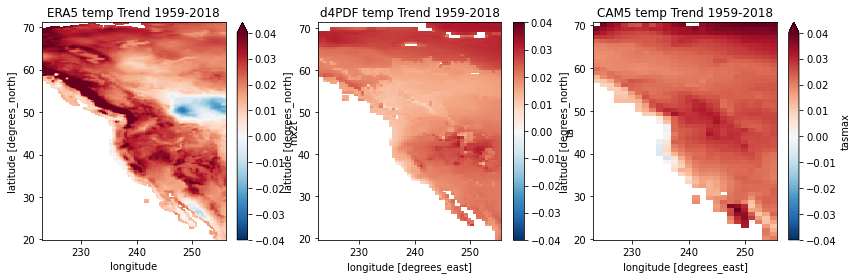

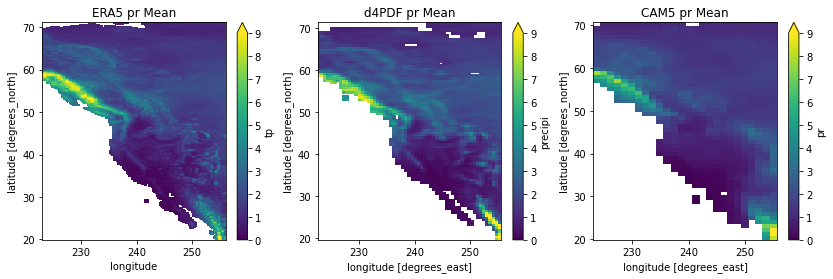

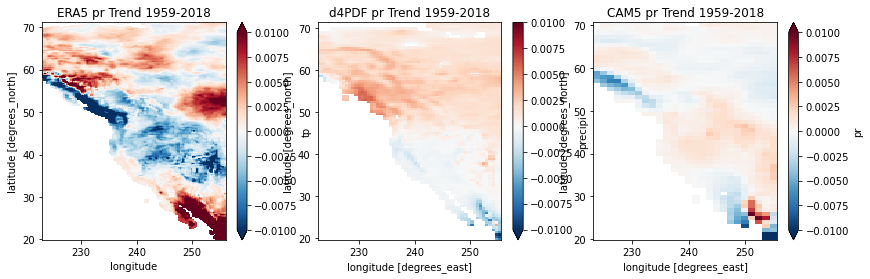

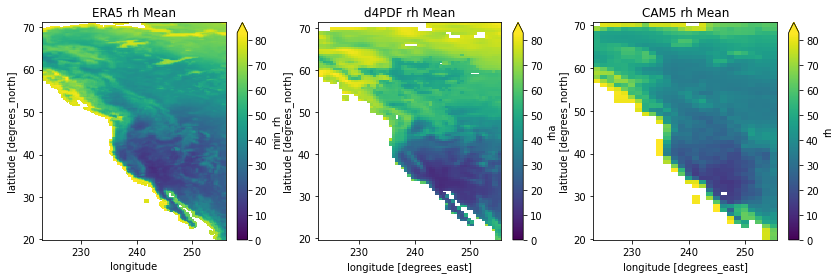

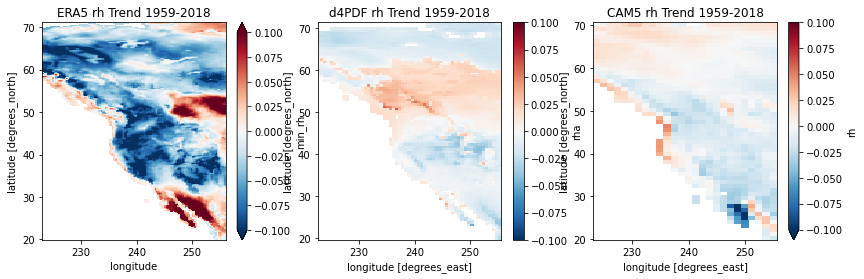

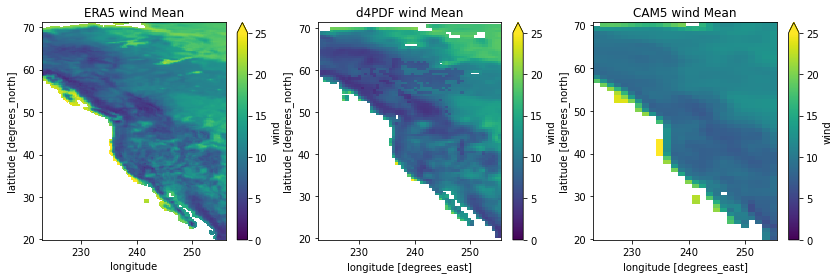

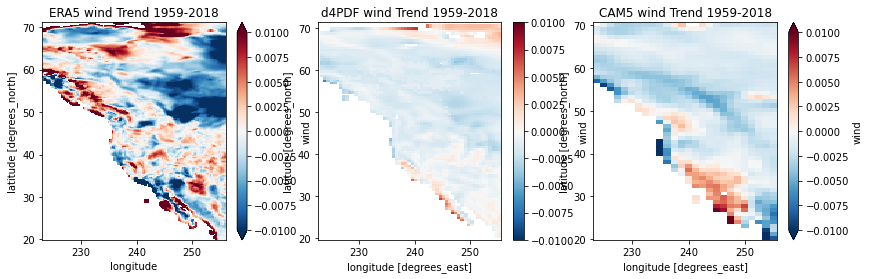

In [57]:
var_dict = {'temp':['mx2t','ta','tasmax'],
            'pr':['tp','precipi','pr'],
            'rh':['min_rh','rha','rh'],
            'wind':['wind','wind','wind']}

t_range_dict = {'temp':[-0.04,0.04],'pr':[-0.01,0.01],'rh':[-0.1,0.1],'wind':[-0.01,0.01]}
m_range_dict = {'temp':[0,40],'pr':[0,9],'rh':[0,83],'wind':[0,25]}

for var in ['temp','pr','rh','wind']:
    for method in ['mean','trend']:
        fig,axs = plt.subplots(1,3,figsize=(14,4))
        axs = axs.flatten()

        das = [ERA5_inputs[var_dict[var][0]], d4pdf_inputs[var_dict[var][1]], cam5_inputs[var_dict[var][2]]]
        names = ['ERA5','d4PDF','CAM5']

        for i,da in enumerate(das):
            da = da.sel(time=slice("1959","2018"))
            da = da.resample(time='A').mean()

            if method == 'mean':
                da.mean('time').plot(ax=axs[i],vmin=m_range_dict[var][0],vmax=m_range_dict[var][1])
                axs[i].set_title(names[i] + " " + var + " Mean")

            if method == 'trend':
                xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],vmin=t_range_dict[var][0],vmax=t_range_dict[var][1],cmap='RdBu_r')
                axs[i].set_title(names[i] + " " + var + " Trend 1959-2018")

        plt.show()
        plt.close(fig)


In [3]:
'''
ERA5 vs d4PDF vs CAM5 95th percentiles
'''

# FWI 95th percentile
ERA5_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/ERA5_FWI_95p_ERA5_resolution.nc')
d4pdf_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_ensMean.nc')
cam5_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_All_ensMean.nc')



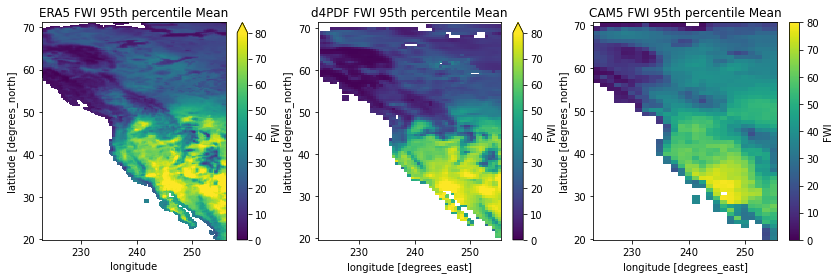

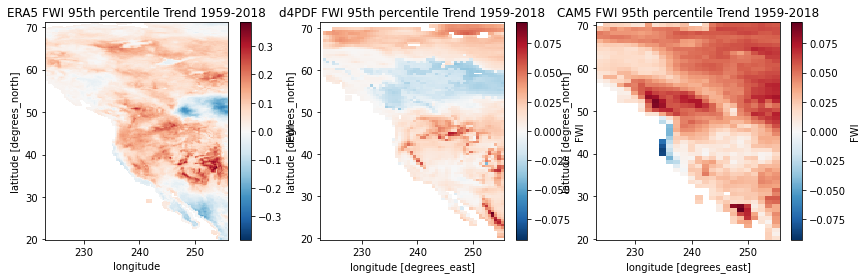

In [4]:
for method in ['mean','trend']:
    fig,axs = plt.subplots(1,3,figsize=(14,4))
    axs = axs.flatten()

    das = [ERA5_95, d4pdf_95, cam5_95]
    names = ['ERA5','d4PDF','CAM5']

    for i,da in enumerate(das):
        da = da.sel(time=slice("1959","2018"))

        if method == 'mean':
            da.mean('time').plot(ax=axs[i],vmin=0,vmax=80)
            axs[i].set_title(names[i] + " FWI 95th percentile Mean")
            
        if method == 'trend':
            xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],cmap='RdBu_r')
            axs[i].set_title(names[i] + " FWI 95th percentile Trend 1959-2018")
            
    plt.show()
    plt.close(fig)
            

In [12]:
ERA5_95 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/ERA5_FWI_95p_ERA5_resolution.nc')


In [15]:
ERA5_95

<xarray.DataArray 'FWI' (time: 71, latitude: 205, longitude: 133)>
[1935815 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 71.0 70.75 70.5 70.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float64 223.0 223.2 223.5 223.8 ... 255.5 255.8 256.0
    quantile   float64 0.95
  * time       (time) datetime64[ns] 1951-01-01 1952-01-01 ... 2021-01-01